In [1]:
import numpy as np
#initialise a vector x containing an example sample
x=np.array([1.3,9.7,3.0,3.4,7.8,5.1,4.5,1.5,3.4,6.7,3.9])
#print the statistics of x
print('Mean value of x:',np.mean(x))
print('Median value of x:',np.median(x))
print('Uncorrected sample standard deviation:',np.std(x))
print('Corrected sample standard deviation:',np.std(x,ddof=1))
iqr_value=np.percentile(x,75)-np.percentile(x,25)
print('IQR:',iqr_value)
cv_value=np.std(x,ddof=1)/np.mean(x)
print('Coefficient of variation:',cv_value*100,'%')

Mean value of x: 4.572727272727272
Median value of x: 3.9
Uncorrected sample standard deviation: 2.4742642282251057
Corrected sample standard deviation: 2.595030215273382
IQR: 2.7
Coefficient of variation: 56.75016375349345 %


In [2]:
import numpy as np
#let us initialise some arrays to be used in place of the PET image and 
# the binary mask for this example
#let the PET image be just a 11*11*11 array of randomly generated values
image_array=np.random.uniform(size=1331).reshape(11,11,11)
#let the mask be a 11*11*11 binary matrix with a 3*3*3 component of 1s 
# in the middle
binary_mask=np.pad(np.ones((3,3,3)),((4,4),(4,4),(4,4)))
#the mean value can now be computed as:
print('Mean of the VOI:',np.sum(image_array*binary_mask)/np.sum(binary_mask))
#next, convert the zeros of the binary mask into NaN values
binary_mask[binary_mask==0]=np.nan
#compute the element-wise product between the PET image and the new mask
arr=image_array*binary_mask
#in the resulting array, the voxels within the VOI stay the same
# (they are multiplied by 1) and the voxels outside the VOI become NaNs.
#consequently, the statistics can be computed over this array
# just by ignoring the NaNs.
#this is possible with numpy's nanmean, nanstd, etc functions
print('Mean of the VOI:',np.nanmean(arr))
print('SD of the VOI:',np.nanstd(arr))
print('Median of the VOI:',np.nanmedian(arr))
print('IQR of the VOI:',np.nanpercentile(arr,75)-np.nanpercentile(arr,25))

Mean of the VOI: 0.5204386847906624
Mean of the VOI: 0.5204386847906624
SD of the VOI: 0.3458877897683621
Median of the VOI: 0.5609861486940798
IQR of the VOI: 0.7143851154397547


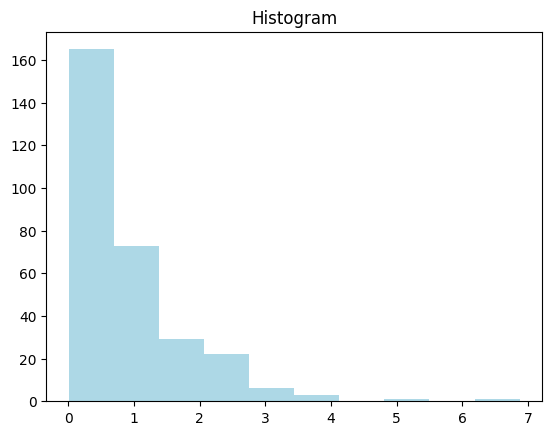

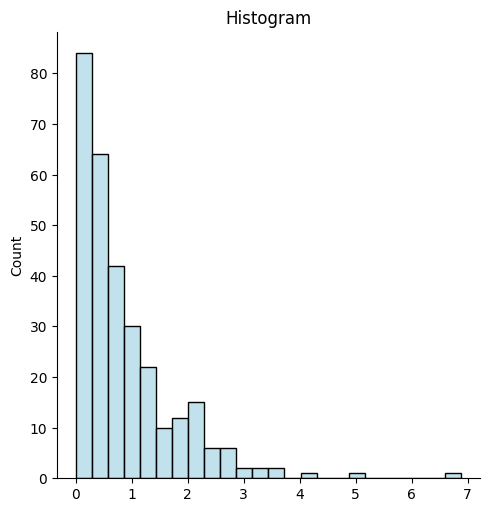

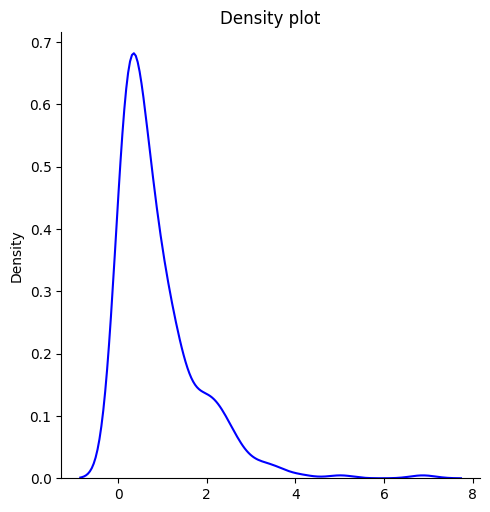

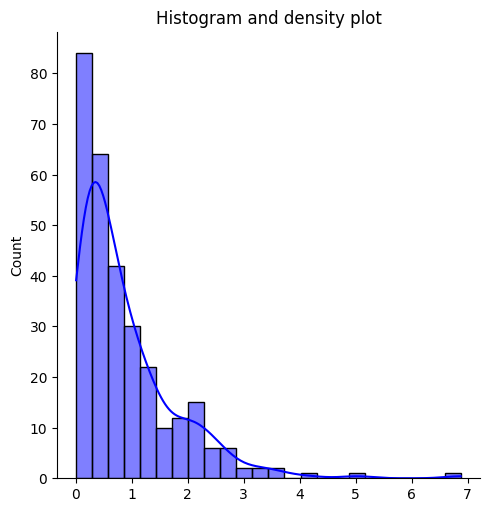

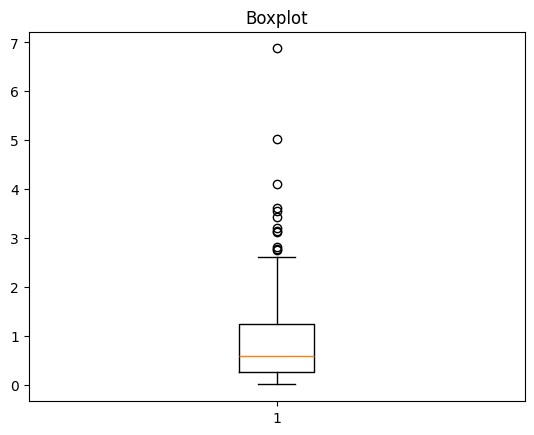

Text(0.5, 1.0, 'Boxplot')

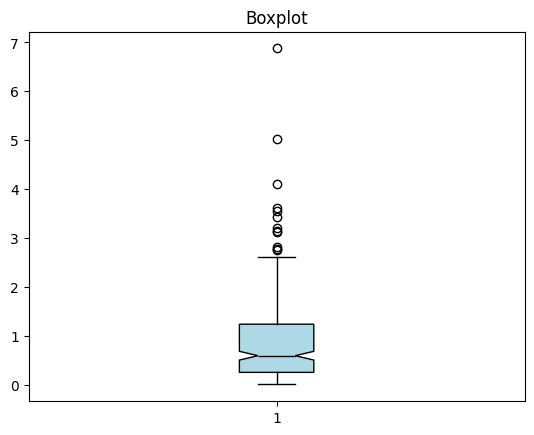

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#initialise the vector x (here, we generate 300 observations from the exponential distribution)
x=np.random.exponential(size=300)
#plot the histogram of x with the matplotlib library
plt.hist(x,color='lightblue')
plt.title('Histogram')
plt.show()
#plot the histogram of x with the seaborn library
sns.displot(x,kind='hist',color='lightblue')
plt.title('Histogram')
plt.show()
#plot the density plot of x
sns.displot(x,kind='kde',color='blue')
plt.title('Density plot')
plt.show()
#plot both the histogram and the density plot of x in the same figure
sns.displot(x,kind='hist',kde='True',color='blue')
plt.title('Histogram and density plot')
plt.show()
#plot the boxplot of x
plt.boxplot(x)
plt.title('Boxplot')
plt.show()
#plot a more visually-pleasing version of the boxplot with notches and custom colors
plt.boxplot(x,notch=True,patch_artist=True,
    boxprops=dict(facecolor='lightblue'),medianprops=dict(color='black'))
plt.title('Boxplot')

In [4]:
from numpy.random import choice
numbers_in_dice=[1,2,3,4,5,6]
number_of_rolls=3
x=choice(numbers_in_dice,size=number_of_rolls,replace=True)
print(x)

[6 1 6]


In [5]:
from numpy.random import uniform
x=uniform(size=1000)

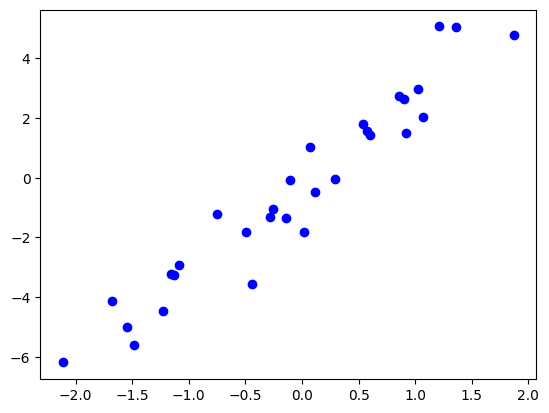

In [6]:
import numpy as np
#initialise two variables, x and y, by generating some values for them
x=np.random.normal(size=30)
y=3*x+np.random.normal(size=30)
#plot y against x (i.e. x is on the horizontal axis, y is on the vertical axis)
plt.scatter(x,y,color='blue')  

In [7]:
import numpy as np
from statsmodels.stats.multitest import fdrcorrection
#suppose that you obtain the following p-values
p_values=np.array([0.03,0.0001,0.55,0.30,0.15,0.45,0.03,0.045,0.015,0.90])
#define the level of significance and the number of tests
alpha=0.05
m=len(p_values)
#check which p-values are statistically significant with and without Bonferroni correction
print('Significant p-values without Bonferroni correction:',p_values[p_values<=alpha])
print('Significant p-values with Bonferroni correction:',p_values[p_values<=alpha/m])
#adjust the p-values with the FDR correction
new_p_values=fdrcorrection(p_values)[1]
print('Adjusted p-values:',new_p_values)
print('Significant p-values after the FDR correction:',new_p_values[new_p_values<=alpha])

Significant p-values without Bonferroni correction: [0.03   0.0001 0.03   0.045  0.015 ]
Significant p-values with Bonferroni correction: [0.0001]
Adjusted p-values: [0.075      0.001      0.61111111 0.42857143 0.25       0.5625
 0.075      0.09       0.075      0.9       ]
Significant p-values after the FDR correction: [0.001]


In [8]:
import numpy as np
from scipy.stats import shapiro
#initialise the variables x and y
x=np.random.normal(size=1000) #x comes from the standard normal distribution
y=np.random.uniform(size=1000) #y is from the uniform distribution (not a normal distribution)
print('Shapiro-Wilk test for x:',shapiro(x))
print('Shapiro-Wilk test for y:',shapiro(y))
#obtain the p-values
p_value_for_x=shapiro(x)[1]
p_value_for_y=shapiro(y)[1]
#print the conclusions for a level of significance alpha=5%
alpha=0.05
print('x is normally distributed according to our test:',p_value_for_x>alpha)
print('y is normally distributed according to our test:',p_value_for_y>alpha)

Shapiro-Wilk test for x: ShapiroResult(statistic=np.float64(0.99853322381983), pvalue=np.float64(0.5764618390169902))
Shapiro-Wilk test for y: ShapiroResult(statistic=np.float64(0.9565504285768834), pvalue=np.float64(1.216240849857448e-16))
x is normally distributed according to our test: True
y is normally distributed according to our test: False


In [9]:
import numpy as np
x=np.array([0.3,0.6,0.9,1.2,1.3,1.4,1.5,1.5,1.6,1.6,1.7,1.8,2.1,2.4,2.7])
y=np.array([0.1,0.2,0.3,0.6,0.9,2.1,2.4,2.7,2.8,2.9,3.0])
z=np.array([0.3,1.2,1.8,2.1,2.4,2.5,2.6,2.7,2.7,2.7,2.7])
w=np.array([0.1,0.3,1.2,1.3,1.8,2.1,2.4,2.5,2.7])

Slope: 2.9292521635174413
Intercept: -0.008778715388185948


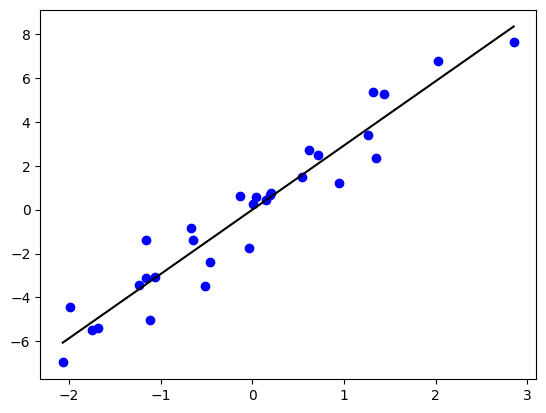

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
#initialise x and y so that there is a clear dependency between them
x=np.random.normal(size=30)
y=3*x+np.random.normal(size=30)
#find the parameters a and b defined as above
b,a,cor_value,p_value,std_err=linregress(x,y)
print('Slope:',b)
print('Intercept:',a)
#plot a scatter plot
plt.scatter(x,y,color='blue')
#plot a line segment of the regression line y=b*x+a between the values min(x) and max(x) of x
plt.plot(np.array([min(x),max(x)]),b*np.array([min(x),max(x)])+a, color='black')

In [11]:
from scipy.stats import shapiro, pearsonr, spearmanr
#let x and y be as before
#check normality
print('Shapiro-Wilk test for x:',shapiro(x))
print('Shapiro-Wilk test for y:',shapiro(y))
#perform correlation tests
print('Pearsons correlation coefficient:', pearsonr(x,y)[0])
print('p-value of Pearsons correlation test:', pearsonr(x,y)[1])
print('Spearmans correlation coefficient:', spearmanr(x,y)[0])
print('p-value of Spearmans correlation test:', spearmanr(x,y)[1])

Shapiro-Wilk test for x: ShapiroResult(statistic=np.float64(0.9762630001438024), pvalue=np.float64(0.7198972730369354))
Shapiro-Wilk test for y: ShapiroResult(statistic=np.float64(0.9776867093868342), pvalue=np.float64(0.7612811346568069))
Pearsons correlation coefficient: 0.960377871785295
p-value of Pearsons correlation test: 4.515616347733908e-17
Spearmans correlation coefficient: 0.9528364849833146
p-value of Spearmans correlation test: 4.941027072964042e-16


In [12]:
import numpy as np
#initialise an empty array
arr=np.empty((4,30))
#fill rows by generating values
arr[0,:]=np.random.normal(size=30)
arr[1,:]=3*arr[0,:]+np.random.normal(size=30)
arr[2,:]=arr[1,:]+np.random.normal(size=30)
arr[3,:]=np.random.normal(size=30)
#print the correlation matrix
print(np.corrcoef(arr))

[[1.         0.95747413 0.93470328 0.15457582]
 [0.95747413 1.         0.9754367  0.20520023]
 [0.93470328 0.9754367  1.         0.17660104]
 [0.15457582 0.20520023 0.17660104 1.        ]]


In [13]:
import numpy as np
x=np.array([0.1,1.1,1.2,-0.4,-1.4,0.5,0.6,0.7,-1.1,0.3,-0.6,-1.0,1.3, 1.7,-0.2])
y=np.array([-0.4,3.2,4.2,-0.5,-2.8,2.0,0.5,2.2, -1.4,0.7,-3.0,-3.6, 5.5,4.1,-1.6])  

In [14]:
import numpy as np
n=100
x=np.random.normal(size=n)
y=x+np.random.normal(size=n)

In [15]:
import numpy as np
x=np.array([-0.7,0.1,-1.3,-0.2,-0.5,0.7,0.8,-0.6,-1.1,1.0,-0.9,-0.4, -1.0,-1.8,0.4,2.3,3.1,2.3,2.8,2.5,3.7,3.8,2.4,1.9,4.0,2.1,2.6,2.0, 2.1,2.0,2.0,1.9])
y=np.array([-0.7,0.3,-1.3,-0.1,-0.5,0.6,0.8,-0.6,-1.0,1.0,-1.1,-0.4, -1.1,-1.9,0.3,-0.7,0.3,-1.3,-0.1,-0.5,0.6,0.8,-0.6,-1.0, 1.0,-1.1,-0.4,-2.0,-1.9,-1.8,-1.6,-1.5])    

Shapiro-Wilk test for x: ShapiroResult(statistic=np.float64(0.9690177342154161), pvalue=np.float64(0.33487530530440524))
Shapiro-Wilk test for y: ShapiroResult(statistic=np.float64(0.9488567305633794), pvalue=np.float64(0.15753695952819463))
Unpaired t-test: TtestResult(statistic=np.float64(-3.478221597000344), pvalue=np.float64(0.0008849100741646861), df=np.float64(68.0))
Mann-Whitney U test: MannwhitneyuResult(statistic=np.float64(317.0), pvalue=np.float64(0.0008003948890937289))


[Text(1, 0, 'x'), Text(2, 0, 'y')]

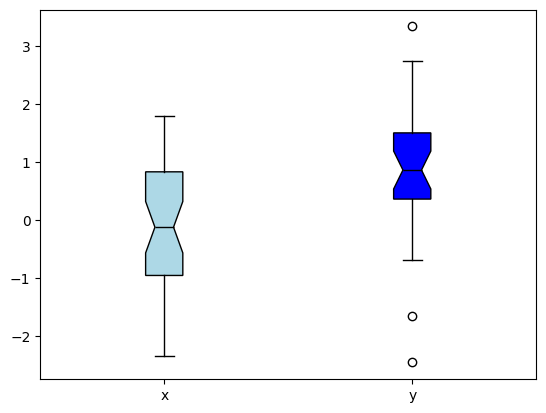

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
#initialise two independent vectors
x=np.random.normal(size=40) #x has 40 observations from the standard normal distribution
y=np.random.normal(loc=1,size=30) #y has 30 observations from the normal distribution with a mean of 1
#check normality
print('Shapiro-Wilk test for x:',shapiro(x))
print('Shapiro-Wilk test for y:',shapiro(y))
#perform tests for a significant difference
print('Unpaired t-test:', ttest_ind(x,y))
print('Mann-Whitney U test:', mannwhitneyu(x,y))
#plot the boxplots of x and y
fig = plt.figure()
ax = fig.add_subplot(111)
bp=ax.boxplot([x,y],notch=True,patch_artist=True,
            boxprops=dict(facecolor='white'),medianprops=dict(color='black'))
colors=['lightblue','blue']
for patch, color in zip(bp['boxes'],colors):
    patch.set_facecolor(color)
ax.set_xticklabels(['x','y'])

In [17]:
import numpy as np
from scipy.stats import shapiro, ttest_rel, wilcoxon
#initialise two paired vectors
x=np.random.normal(size=30)
y=x+np.random.normal(loc=0.5,size=30)
#check normality
print('Shapiro-Wilk test for x:',shapiro(x))
print('Shapiro-Wilk test for y:',shapiro(y))
#perform tests for a significant difference
print('Paired t-test:', ttest_rel(x,y))
print('Wilcoxon signed-rank test:', wilcoxon(x,y))
#compute the mean values
print('mean value of x:',np.mean(x))
print('mean value of y:',np.mean(y))

Shapiro-Wilk test for x: ShapiroResult(statistic=np.float64(0.9805986053164403), pvalue=np.float64(0.8412415698196499))
Shapiro-Wilk test for y: ShapiroResult(statistic=np.float64(0.9706439925152959), pvalue=np.float64(0.5569438800553388))
Paired t-test: TtestResult(statistic=np.float64(-2.6011167108171773), pvalue=np.float64(0.01447638869466872), df=np.int64(29))
Wilcoxon signed-rank test: WilcoxonResult(statistic=np.float64(116.0), pvalue=np.float64(0.015460003167390823))
mean value of x: -0.024095608779871745
mean value of y: 0.45647470498787956


In [18]:
import numpy as np
from scipy.stats import shapiro, f_oneway, kruskal, mannwhitneyu
#initialise three independent vectors
x=np.random.normal(size=50)
y=np.random.normal(loc=1,size=60)
z=np.random.normal(size=70)
#check normality
print('Shapiro-Wilk test for x:',shapiro(x))
print('Shapiro-Wilk test for y:',shapiro(y))
print('Shapiro-Wilk test for z:',shapiro(z))
#perform tests for a significant difference
print('One-way ANOVA:', f_oneway(x,y,z))
print('Kruskal-Wallis test:', kruskal(x,y,z))
#compute the mean values
print('mean value of x:',np.mean(x))
print('mean value of y:',np.mean(y))
print('mean value of z:',np.mean(z))
#perform more tests between two variables (unpaired t-test or Mann-Whitney U)
print('Mann-Whitney U for x vs y:', mannwhitneyu(x,y))
print('Mann-Whitney U test for x vs z:', mannwhitneyu(x,z))
print('Mann-Whitney U test for y vs z:', mannwhitneyu(y,z))

Shapiro-Wilk test for x: ShapiroResult(statistic=np.float64(0.9708360773311471), pvalue=np.float64(0.2502179330279537))
Shapiro-Wilk test for y: ShapiroResult(statistic=np.float64(0.9812591853736167), pvalue=np.float64(0.484071903325454))
Shapiro-Wilk test for z: ShapiroResult(statistic=np.float64(0.9884669713155392), pvalue=np.float64(0.7719097423361736))
One-way ANOVA: F_onewayResult(statistic=np.float64(27.59820113515007), pvalue=np.float64(3.693376071256478e-11))
Kruskal-Wallis test: KruskalResult(statistic=np.float64(41.65279873717441), pvalue=np.float64(9.020065190289643e-10))
mean value of x: -0.02979029883647477
mean value of y: 1.1217463746713963
mean value of z: -0.08053191448560305
Mann-Whitney U for x vs y: MannwhitneyuResult(statistic=np.float64(654.0), pvalue=np.float64(3.8640030024124705e-07))
Mann-Whitney U test for x vs z: MannwhitneyuResult(statistic=np.float64(1805.0), pvalue=np.float64(0.7717332514298038))
Mann-Whitney U test for y vs z: MannwhitneyuResult(statistic

In [19]:
import numpy as np
from scipy.stats import chisquare, fisher_exact
#create a small 2*2 contingency table
table_1=np.array([[13,10],[11,6]])
print(table_1)
#perform the chi-squared and Fishers exact test 
print('Chi-squared test:',chisquare(table_1,axis=None))
print('Fishers exact test:',fisher_exact(table_1))
#create a larger contingency table
table_2=np.array([[134,567,93],[400,750,259]])
print(table_2)
#perform the chi-squared test
print(chisquare(table_2,axis=None))

[[13 10]
 [11  6]]
Chi-squared test: Power_divergenceResult(statistic=np.float64(2.6), pvalue=np.float64(0.45748954687818333))
Fishers exact test: SignificanceResult(statistic=np.float64(0.7090909090909091), pvalue=np.float64(0.747141134460378))
[[134 567  93]
 [400 750 259]]
Power_divergenceResult(statistic=np.float64(895.5247389922831), pvalue=np.float64(2.475500286585237e-191))


In [20]:
import numpy as np
from math import log
from scipy.stats import pearsonr,spearmanr
#initialise some ground-truth values and predictions
ground_truth_values=np.array([1.1,1.3,2.4,5.6,1.5,3.3,4.5,8.9,9.3,7.4,5.6])
predictions=np.array([1.0,1.3,2.6,5.1,2.5,3.1,3.5,9.6,5.9,3.4,6.6])
#compute the errors terms according to their formulas
mae=np.mean(abs(ground_truth_values-predictions))
mse=np.mean((ground_truth_values-predictions)**2)
rmse=mse**0.5
mre=np.mean(abs(ground_truth_values-predictions)/ground_truth_values)
#here, let's choose some number of model parameters for the sake of our example
numberOfModelParameters=4
#compute BIC and AIC
n=len(predictions)
aic=n*log(mse)+2*numberOfModelParameters
bic=n*log(mse)+numberOfModelParameters*log(n)
#compute correlation coefficients
cor_pearson=pearsonr(ground_truth_values,predictions)[0]
cor_spearman=spearmanr(ground_truth_values,predictions)[0]
#print the results
print('MAE:',round(mae,3))
print('MSE:',round(mse,3))
print('RMSE:',round(rmse,3))
print('MRE:',round(mre*100,1),'%')
print('AIC:',round(aic,3))
print('BIC:',round(bic,3))
print('Pearsons correlation coefficient:',round(cor_pearson,3))
print('Spearmans correlation coefficient:',round(cor_spearman,3))

MAE: 1.1
MSE: 2.854
RMSE: 1.689
MRE: 21.6 %
AIC: 19.535
BIC: 21.126
Pearsons correlation coefficient: 0.831
Spearmans correlation coefficient: 0.902


In [21]:
import numpy as np
import pandas as pd
#initialise some values for the predicted and the ground-truth labels
ground_truth_labels=np.array([0,0,0,1,0,1,1,0,1,0,1,0,1,1,1,0,0,0,1,1,0])
predicted_labels=np.array([1,0,0,0,0,1,0,0,1,1,1,1,1,1,1,0,0,1,1,0,1])
#compute the TP, TN, FN, and FP counts from these binary label predictions
TP=np.sum(predicted_labels[ground_truth_labels==1]==1)
TN=np.sum(predicted_labels[ground_truth_labels==0]==0)
FN=np.sum(predicted_labels[ground_truth_labels==1]==0)
FP=np.sum(predicted_labels[ground_truth_labels==0]==1)
#produce the confusion matrix from the resulting TP, TN, FN, and FP counts
confusionMatrix=pd.DataFrame(np.array([[TP,FP],[FN,TN]]),
    columns=['Ground-truth pos.','Ground-truth neg.'],
    index=['Predicted as pos.','Predicted as neg.'])
print('Confusion matrix:')
print(confusionMatrix)
#compute the four evaluation metrics from the TP, TN, FN, and FP counts
acc=(TP+TN)/(TP+TN+FN+FP)
sen=TP/(TP+FN)
spe=TN/(TN+FP)
pre=TP/(TP+FP)
print('Accuracy:',round(acc*100,1),'%')
print('Sensitivity:',round(sen*100,1),'%')
print('Specificity:',round(spe*100,1),'%')
print('Precision:',round(pre*100,1),'%')

Confusion matrix:
                   Ground-truth pos.  Ground-truth neg.
Predicted as pos.                  7                  5
Predicted as neg.                  3                  6
Accuracy: 61.9 %
Sensitivity: 70.0 %
Specificity: 54.5 %
Precision: 58.3 %


In [22]:
import numpy as np
#initialise some values for the ground-truth labels
ground_truth_labels=np.array([0,0,0,1,0,1,1,0,1,0,1,0,1,1,1,0,0,0,1,1,0,1])
predictions=np.array([0.92,0.02,0.03,0.06,0.19,0.93,0.46,0.34,0.96,0.45,
    0.99,0.67,0.76,0.84,0.39,0.13,0.26,0.53,0.89,0.92,0.14,0.78])
for threshold in [0.3,0.6,0.9]:
    TP=np.sum(predictions[ground_truth_labels==1]>=threshold)
    TN=np.sum(predictions[ground_truth_labels==0]<threshold)
    FN=np.sum(predictions[ground_truth_labels==1]<threshold)
    FP=np.sum(predictions[ground_truth_labels==0]>=threshold)
    acc=(TP+TN)/(TP+TN+FN+FP)
    sen=TP/(TP+FN)
    spe=TN/(TN+FP)
    pre=TP/(TP+FP)
    print('When threshold is:',threshold)
    print('Accuracy:',round(acc*100,1),'%')
    print('Sensitivity:',round(sen*100,1),'%')
    print('Specificity:',round(spe*100,1),'%')
    print('Precision:',round(pre*100,1),'%')
    print('---')

When threshold is: 0.3
Accuracy: 72.7 %
Sensitivity: 90.9 %
Specificity: 54.5 %
Precision: 66.7 %
---
When threshold is: 0.6
Accuracy: 77.3 %
Sensitivity: 72.7 %
Specificity: 81.8 %
Precision: 80.0 %
---
When threshold is: 0.9
Accuracy: 63.6 %
Sensitivity: 36.4 %
Specificity: 90.9 %
Precision: 80.0 %
---


Number of unique predictions: 21
Number of thresholds: 22


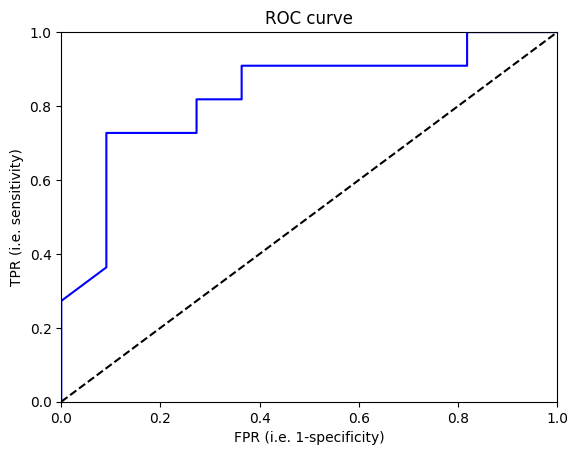

AUC: 0.831


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
#initialise again some values for the ground-truth labels and numeric predictions
ground_truth_labels=np.array([0,0,0,1,0,1,1,0,1,0,1,0,1,1,1,0,0,0,1,1,0,1])
predictions=np.array([0.92,0.02,0.03,0.06,0.19,0.93,0.46,0.34,0.96,0.45,
    0.99,0.67,0.76,0.84,0.39,0.13,0.26,0.53,0.89,0.92,0.14,0.78])
#use a ready function to produce the potential threshold selections and the corresponding TPR and FPR values
fpr, tpr, thresholds = roc_curve(ground_truth_labels, predictions, drop_intermediate=False)
#you can check that the number of thresholds is n+1 where n is the number of unique predictions
print('Number of unique predictions:',len(np.unique(predictions)))
print('Number of thresholds:',len(thresholds))
#plot the ROC curve
plt.figure()
#ROC is plotted as a solid blue line
plt.plot(fpr,tpr,'b-')
#add a dashed black line segment showing the performance of a random classifier
plt.plot([0,1],[0,1],'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel('FPR (i.e. 1-specificity)')
plt.ylabel('TPR (i.e. sensitivity)')
plt.title('ROC curve')
plt.show()
#use another ready function to compute the AUC
auc_value = auc(fpr,tpr)
print('AUC:',round(auc_value,3))

In [24]:
import numpy as np
from sklearn.metrics import roc_curve
#initialise groundTruthLabels and predictions
ground_truth_labels=np.array([0,0,0,1,0,1,1,0,1,0,1,0,1,1,1,0,0,0,1,1,0,1])
predictions=np.array([0.92,0.02,0.03,0.06,0.19,0.93,0.46,0.34,0.96,0.45,
    0.99,0.67,0.76,0.84,0.39,0.13,0.26,0.53,0.89,0.92,0.14,0.78])
#use a ready function to produce the potential threshold selections and the corresponding TPR and FPR values
fpr, tpr, thresholds = roc_curve(ground_truth_labels, predictions, drop_intermediate=False)
#choose the threshold with the maximal Youden's index
youden_threshold = thresholds[np.argmax(tpr - fpr)]
print('Threshold with maximal Youdens index:',youden_threshold)

Threshold with maximal Youdens index: 0.76


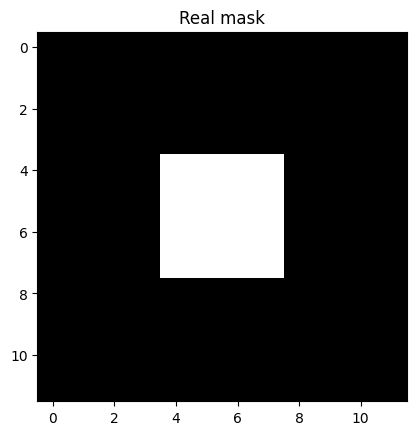

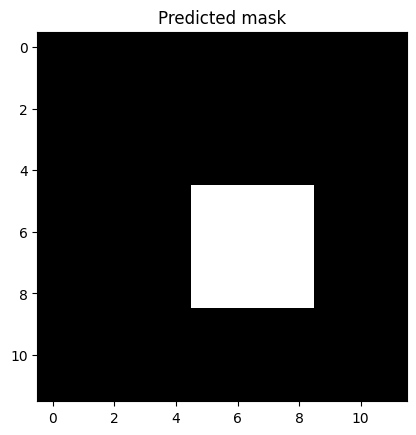

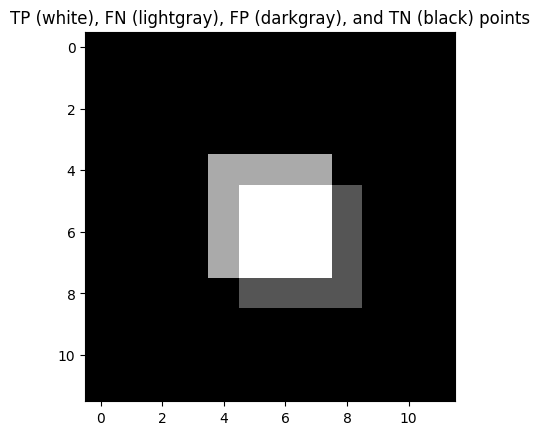

Dice: 0.562
IoU: 0.391
Dice (computed from TP, FN, and FP numbers): 0.562
IoU (computed from TP, FN, and FP numbers): 0.391


In [25]:
import numpy as np
import matplotlib.pyplot as plt
#initialise some choices for the real and the predicted masks
real_mask=np.pad(np.ones((4,4)),((4,4),(4,4)))
predicted_mask=np.pad(np.ones((4,4)),((5,3),(5,3)))
#plot the real and the predicted mask
plt.imshow(real_mask,cmap='gray')
plt.title('Real mask')
plt.show()
plt.imshow(predicted_mask,cmap='gray')
plt.title('Predicted mask')
plt.show()
#plot a single image where TP points are in white, FN points in lightgray, FP points in darkgray, TN points in black
plt.imshow(predicted_mask+2*real_mask,cmap='gray')
plt.title('TP (white), FN (lightgray), FP (darkgray), and TN (black) points')
plt.show()
#the intersection of the two binary masks is their element-wise minimum
intersection=np.minimum(real_mask,predicted_mask)
#the union of the two binary masks is their element-wise maximum
union=np.maximum(real_mask,predicted_mask)
#compute Dice and IoU (here, np.sum is used to obtain the number of positive points in a binary matrix)
dice=2*np.sum(intersection)/(np.sum(real_mask)+np.sum(predicted_mask))
iou=np.sum(intersection)/(np.sum(union))
print('Dice:',round(dice,3))
print('IoU:',round(iou,3))
#alternatively:
TP=np.sum(predicted_mask[real_mask==1]==1)
FN=np.sum(predicted_mask[real_mask==1]==0)
FP=np.sum(predicted_mask[real_mask==0]==1)
print('Dice (computed from TP, FN, and FP numbers):',round(2*TP/(2*TP+FN+FP),3))
print('IoU (computed from TP, FN, and FP numbers):',round(TP/(TP+FN+FP),3))